# 05. EDA: Visualizing Data Distributions and Relationships
## 📚 Learning Objectives

By completing this notebook, you will:
- Perform exploratory data analysis (EDA) through visualization
- Visualize data distributions (histograms, box plots, density plots)
- Visualize relationships (scatter plots, correlation heatmaps)
- Discover patterns and insights
- Use Matplotlib and Seaborn effectively

## 🔗 Prerequisites

- ✅ Example 1: Data Loading (need data first)
- ✅ Example 2: Missing Values (clean data first)
- ✅ Understanding of pandas DataFrames
- ✅ Basic visualization concepts

> **Note on plotting commands**: the matplotlib/seaborn calls in this notebook are
> used as given, with inline commentary — Unit 3 teaches both libraries in depth.

---

This notebook covers practical activities from **Course 05, Unit 2**:
- Performing EDA: Visualizing data distributions and relationships to discover insights

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Data Loading** - You need data loaded!
- ✅ **Example 2: Missing Values** - Data should be cleaned!
- ✅ **Understanding of data types**: What are distributions? What are relationships?

**If you haven't completed these**, you might struggle with:
- Understanding what to visualize
- Knowing which chart type to use
- Interpreting visualizations

---

## 🔗 Where This Notebook Fits

**This is part of Unit 2: Data Cleaning and Preparation**

**Why EDA visualization?**
- **After** cleaning data, we need to understand it
- **Before** building models, we explore patterns
- **Visualization** helps us see what statistics can't show
- **Relationships** reveal insights for feature engineering

**Builds on**: 
- 📓 Example 2: Missing Values (clean data first)
- 📓 Data cleaning techniques

**Leads to**: 
- 📓 Example 6: Statistical EDA (complements visual EDA)
- 📓 Unit 3: Data Visualization (more advanced techniques)
- 📓 Unit 4: Machine Learning (EDA informs feature selection)

**Why this order?**
1. EDA reveals data patterns (essential before modeling)
2. Visualization makes patterns visible (easier than numbers)
3. Insights guide feature engineering and model selection

---

## The Story: Exploring a New City

Imagine you're exploring a new city. **Before** planning your route, you look at a map - see where things are, find interesting areas, discover connections. **After** exploring visually, you understand the city layout!

Same with data: **Before** building models, we visualize data - see distributions, find patterns, discover relationships. **After** exploring visually, we understand our data!

---

## Why EDA Visualization Matters

EDA visualization is essential because:
- **See Patterns**: Visuals reveal patterns numbers can't show
- **Detect Outliers**: Charts make outliers obvious
- **Understand Relationships**: Scatter plots show correlations
- **Communicate Insights**: Visuals are easier to understand than tables

**Common Student Questions:**
- **Q: Which chart should I use?**
  - Answer: Histogram for distributions, scatter for relationships, box plot for outliers
  - Example: Age distribution → histogram, Age vs Income → scatter plot
  - Rule: Distribution → histogram/box, Relationship → scatter/heatmap
  
- **Q: Why visualize if I have statistics?**
  - Answer: Visuals show patterns, outliers, and relationships that statistics miss
  - Example: Statistics show mean=50, but histogram shows two peaks (bimodal)
  - Benefit: Visuals reveal insights statistics can't capture

---

## Introduction

**Exploratory Data Analysis (EDA)** involves visualizing data distributions and relationships to discover patterns, anomalies, and insights. Visualization makes data exploration intuitive and reveals insights that statistics alone cannot show.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Clean dataset
- pandas, matplotlib, seaborn

**Outputs:** What you'll see when you run the cells

- EDA plots
- Insights

---

In [1]:
# WHAT: Import the plotting stack (pandas, NumPy, matplotlib, seaborn).
# WHY: EDA means looking at data - these four libraries generate and draw everything in this notebook.

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# WHAT: Load the real Titanic manifest and prepare the columns this notebook explores.
# WHY: EDA is about discovering what is in YOUR data - which only means something if the data was not invented to look nice.

# ============================================================================
# PART 1: THE DATA
# ============================================================================
print("-" * 70)

DATA_DIR = '../../../Course 04/datasets/raw/'
df = pd.read_csv(DATA_DIR + 'titanic.csv')

# Age has 177 genuinely missing values. Fill by (class, sex) median, as Example 2
# concluded, so the plots below are not silently dropping a fifth of the ship.
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda s: s.fillna(s.median()))
df['family_size'] = df['SibSp'] + df['Parch'] + 1

print("Real dataset loaded (Titanic passenger manifest):")
print(df[['Age', 'Fare', 'family_size', 'Pclass', 'Sex', 'Survived']].head())
print(f"\nDataset shape: {df.shape}")
print(f"Passengers: {len(df)}  |  Survivors: {int(df['Survived'].sum())}"
      f"  |  Survival rate: {df['Survived'].mean():.1%}")

# ============================================================================


----------------------------------------------------------------------
Real dataset loaded (Titanic passenger manifest):
    Age     Fare  family_size  Pclass     Sex  Survived
0  22.0   7.2500            2       3    male         0
1  38.0  71.2833            2       1  female         1
2  26.0   7.9250            1       3  female         1
3  35.0  53.1000            2       1  female         1
4  35.0   8.0500            1       3    male         0

Dataset shape: (891, 13)
Passengers: 891  |  Survivors: 342  |  Survival rate: 38.4%



PART 2: Distribution Visualizations

✅ Example 1: Histogram (Frequency Distribution)
----------------------------------------------------------------------


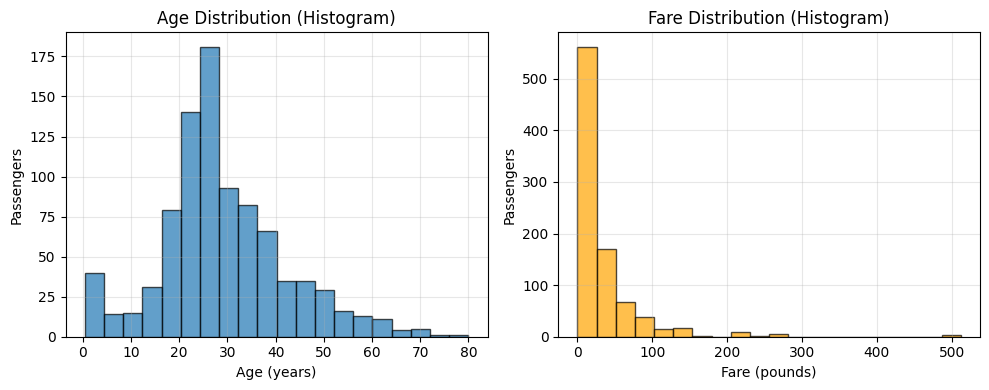

💡 Histograms show: How data is distributed, peaks, spread
   Age is roughly bell-shaped (skew 0.53), centred near 26.
   Fare is not (skew 4.79): almost everyone is in the
   first bin and a few tickets reach 512 pounds.
   Two columns from the same file, two completely different shapes.

✅ Example 2: Box Plot (Quartiles and Outliers)
----------------------------------------------------------------------


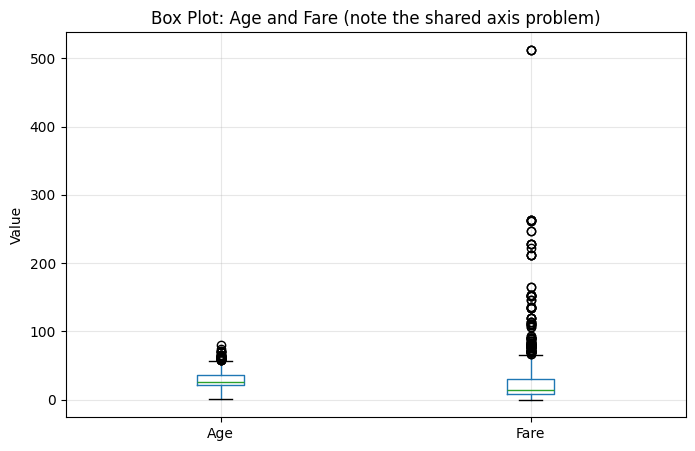

💡 Box plots show: Median, quartiles, outliers, spread
   ⚠ Plotted on one axis, Fare's range flattens Age into a line. On real
     data with different units, plot each column on its own axis or scale
     them first (Example 4 in this unit).


In [3]:
# WHAT: Draw histograms and box plots of the real Age and Fare columns.
# WHY: Distribution plots answer 'what does a typical value look like, and how far do the extremes reach?'

# ============================================================================
# PART 2: DISTRIBUTION VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 70)
print("PART 2: Distribution Visualizations")
print("=" * 70)

# Histogram
print("\n✅ Example 1: Histogram (Frequency Distribution)")
print("-" * 70)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['Age'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Age (years)')
plt.ylabel('Passengers')
plt.title('Age Distribution (Histogram)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df['Fare'], bins=20, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Fare (pounds)')
plt.ylabel('Passengers')
plt.title('Fare Distribution (Histogram)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("💡 Histograms show: How data is distributed, peaks, spread")
print(f"   Age is roughly bell-shaped (skew {df['Age'].skew():.2f}), centred near"
      f" {df['Age'].median():.0f}.")
print(f"   Fare is not (skew {df['Fare'].skew():.2f}): almost everyone is in the")
print(f"   first bin and a few tickets reach {df['Fare'].max():.0f} pounds.")
print("   Two columns from the same file, two completely different shapes.")

# Box Plot
print("\n✅ Example 2: Box Plot (Quartiles and Outliers)")
print("-" * 70)
plt.figure(figsize=(8, 5))
df[['Age', 'Fare']].boxplot()
plt.ylabel('Value')
plt.title('Box Plot: Age and Fare (note the shared axis problem)')
plt.grid(True, alpha=0.3)
plt.show()
print("💡 Box plots show: Median, quartiles, outliers, spread")
print("   ⚠ Plotted on one axis, Fare's range flattens Age into a line. On real")
print("     data with different units, plot each column on its own axis or scale")
print("     them first (Example 4 in this unit).")



PART 3: Relationship Visualizations

✅ Example 3: Scatter Plot (Two Variables)
----------------------------------------------------------------------


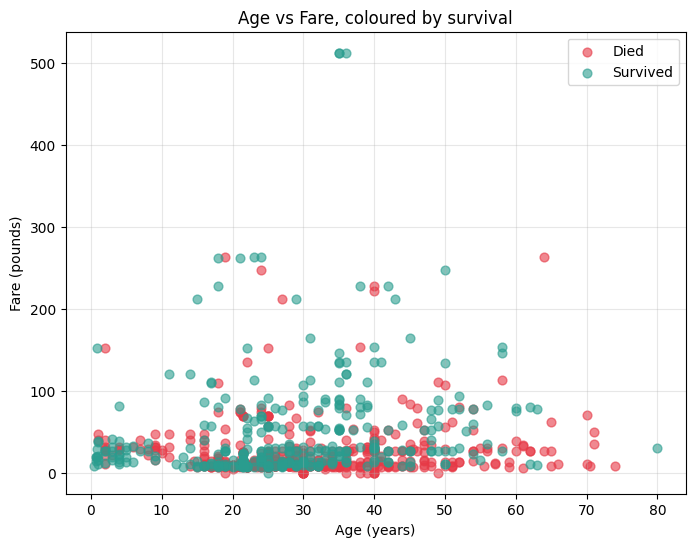

💡 Scatter plots show: Relationships, correlations, clusters
   Honest reading: Age and Fare barely move together (r = 0.12).
   Older passengers were NOT systematically richer. Real data often refuses
   to show the relationship you hoped for - report that, do not hide it.
   What the colours DO show: the green points cluster at high fares.

✅ Example 4: Correlation Heatmap (Multiple Variables)
----------------------------------------------------------------------


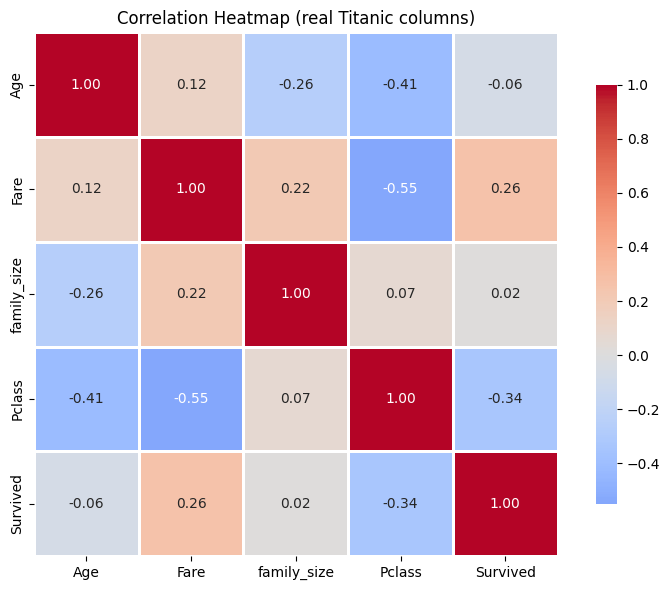

💡 Heatmaps show: Correlations between all variable pairs
   Strongest link with survival: Pclass at -0.34
   (negative because class 3 is the WORST class, not the best).
   Fare vs Pclass: -0.55 - unsurprising, they
   measure nearly the same thing. Two near-duplicate features is something
   a model will care about (Unit 4).


In [4]:
# WHAT: Explore relationships between the real numeric columns with a scatter plot and a correlation heatmap.
# WHY: Relationship plots answer 'does knowing one column tell me anything about another?' - sometimes the honest answer is no.

# ============================================================================
# PART 3: RELATIONSHIP VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 70)
print("PART 3: Relationship Visualizations")
print("=" * 70)

# Scatter Plot
print("\n✅ Example 3: Scatter Plot (Two Variables)")
print("-" * 70)
plt.figure(figsize=(8, 6))
# Colour by survival so the scatter carries a third variable for free.
for survived, colour, label in [(0, '#E63946', 'Died'), (1, '#2A9D8F', 'Survived')]:
    subset = df[df['Survived'] == survived]
    plt.scatter(subset['Age'], subset['Fare'], alpha=0.6, s=40, c=colour, label=label)
plt.xlabel('Age (years)')
plt.ylabel('Fare (pounds)')
plt.title('Age vs Fare, coloured by survival')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
r_age_fare = df['Age'].corr(df['Fare'])
print("💡 Scatter plots show: Relationships, correlations, clusters")
print(f"   Honest reading: Age and Fare barely move together (r = {r_age_fare:.2f}).")
print("   Older passengers were NOT systematically richer. Real data often refuses")
print("   to show the relationship you hoped for - report that, do not hide it.")
print("   What the colours DO show: the green points cluster at high fares.")

# Correlation Heatmap
print("\n✅ Example 4: Correlation Heatmap (Multiple Variables)")
print("-" * 70)
correlation = df[['Age', 'Fare', 'family_size', 'Pclass', 'Survived']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap (real Titanic columns)')
plt.tight_layout()
plt.show()
print("💡 Heatmaps show: Correlations between all variable pairs")
print(f"   Strongest link with survival: Pclass at {correlation.loc['Pclass', 'Survived']:.2f}")
print("   (negative because class 3 is the WORST class, not the best).")
print(f"   Fare vs Pclass: {correlation.loc['Fare', 'Pclass']:.2f} - unsurprising, they")
print("   measure nearly the same thing. Two near-duplicate features is something")
print("   a model will care about (Unit 4).")



PART 4: Categorical Visualizations

✅ Example 5: Bar Plot (Categorical Data)
----------------------------------------------------------------------


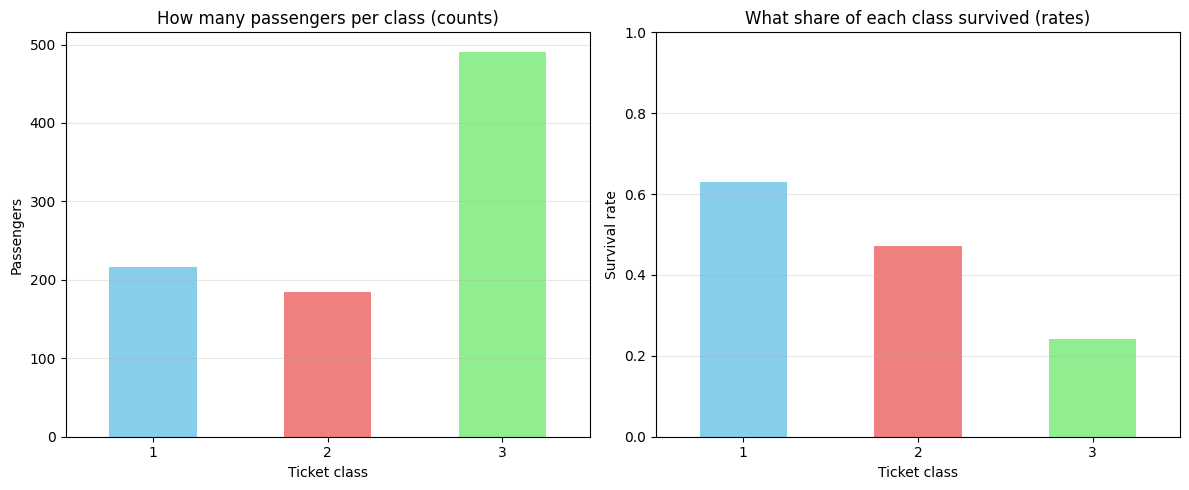

💡 Bar plots show: Counts, frequencies, comparisons
   Counts per class: {1: 216, 2: 184, 3: 491}
   Survival rate per class: {1: 0.63, 2: 0.473, 3: 0.242}
   ⚠ The two charts tell opposite stories. Class 3 had the MOST passengers
     (491) and the FEWEST survivors proportionally
     (24% vs 63% in class 1).
     Always be explicit about whether a bar is a count or a rate.

Summary

✅ What you learned:
   1. Distribution Visualizations: Histograms, box plots (understand data spread)
   2. Relationship Visualizations: Scatter plots, heatmaps (find correlations)
   3. Categorical Visualizations: Bar plots (compare categories)
   4. EDA Goals: Understand structure, find patterns, detect outliers
   5. Reporting honestly when a hoped-for relationship simply is not there

🎯 Key Takeaways:
   - Histograms: Show frequency distributions
   - Box plots: Show quartiles and outliers (mind the shared axis)
   - Scatter plots: Show relationships between variables
   - Heatmaps: Show correlations b

In [5]:
# WHAT: Compare the real categories - how many passengers per class, and what share of each class survived.
# WHY: A count bar chart and a rate bar chart answer different questions, and confusing them is a classic reporting error.

# ============================================================================
# PART 4: CATEGORICAL VISUALIZATIONS
# ============================================================================
print("\n" + "=" * 70)
print("PART 4: Categorical Visualizations")
print("=" * 70)

# Bar Plot
print("\n✅ Example 5: Bar Plot (Categorical Data)")
print("-" * 70)
category_counts = df['Pclass'].value_counts().sort_index()
survival_rate = df.groupby('Pclass')['Survived'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
category_counts.plot(kind='bar', ax=axes[0],
                     color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0].set_xlabel('Ticket class')
axes[0].set_ylabel('Passengers')
axes[0].set_title('How many passengers per class (counts)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

survival_rate.plot(kind='bar', ax=axes[1],
                   color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1].set_xlabel('Ticket class')
axes[1].set_ylabel('Survival rate')
axes[1].set_ylim(0, 1)
axes[1].set_title('What share of each class survived (rates)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("💡 Bar plots show: Counts, frequencies, comparisons")
print("   Counts per class:", category_counts.to_dict())
print("   Survival rate per class:",
      {k: round(v, 3) for k, v in survival_rate.to_dict().items()})
print("   ⚠ The two charts tell opposite stories. Class 3 had the MOST passengers")
print(f"     ({category_counts.loc[3]}) and the FEWEST survivors proportionally")
print(f"     ({survival_rate.loc[3]:.0%} vs {survival_rate.loc[1]:.0%} in class 1).")
print("     Always be explicit about whether a bar is a count or a rate.")

# ============================================================================
# ============================================================================
print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("""
✅ What you learned:
   1. Distribution Visualizations: Histograms, box plots (understand data spread)
   2. Relationship Visualizations: Scatter plots, heatmaps (find correlations)
   3. Categorical Visualizations: Bar plots (compare categories)
   4. EDA Goals: Understand structure, find patterns, detect outliers
   5. Reporting honestly when a hoped-for relationship simply is not there

🎯 Key Takeaways:
   - Histograms: Show frequency distributions
   - Box plots: Show quartiles and outliers (mind the shared axis)
   - Scatter plots: Show relationships between variables
   - Heatmaps: Show correlations between all variables
   - Bar plots: Show categorical frequencies - counts and rates are different

📚 Next Steps:
   - Example 6: Statistical EDA (complements visual EDA)
   - Unit 3: Data Visualization (more advanced techniques)
   - Use EDA insights for feature engineering
""")
print("✅ EDA visualization concepts understood!")


## 📚 References

1. Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
2. Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90-95. <https://doi.org/10.1109/MCSE.2007.55>
3. Waskom, M. L. (2021). *seaborn: Statistical Data Visualization*. Journal of Open Source Software, 6(60), 3021. <https://joss.theoj.org/papers/10.21105/joss.03021>